# O*NET Task Mapping Validation (Snippet → LLM Judge)

**Notebook purpose**: Map each survey task snippet (Q13/Q14 open text) to O*NET task statements using a two-stage approach:
1. **Embedding retrieval**: Find top-5 candidate O*NET statements for each snippet
2. **LLM adjudication**: Verify whether any candidate is a valid match

**Outputs**: Coverage metrics, match quality, concordance tables, taxonomy gaps, and downstream agreement checks with exposure scores.

**Out of scope**: Sector exposure rankings or automation-risk claims. This notebook validates taxonomy alignment.

In [1]:
#|hide
import nblite; from nbdev.showdoc import show_doc; nblite.nbl_export()

/Users/bhargav/adu_dev/aisi-economy-index/.venv/lib/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [2]:
# =============================================================================
# A.1 IMPORTS AND CONFIGURATION
# =============================================================================
import pandas as pd
import numpy as np
from pathlib import Path
import json
import hashlib
import re
import os
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f"Run timestamp: {datetime.now().isoformat()}")

Run timestamp: 2026-02-02T14:30:56.269213


In [3]:
# =============================================================================
# A.2 PATHS AND CONFIGURATION
# =============================================================================
# Base paths (use relative paths, not hard-coded user paths)
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
CACHE_DIR = BASE_DIR / "cache"
OUTPUT_DIR = BASE_DIR / "outputs" / "validation_llm"

# Create directories
CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Input files
SURVEY_OPEN_TEXT = BASE_DIR / "outputs" / "survey_only" / "open_text_responses.csv"

# O*NET tasks - use environment variable or default path
ONET_TASKS_DEFAULT = Path(__file__).parent.parent.parent / "aisi_economy_index" / "store" / "data" / "eval_dfs" / "tasks_eval.csv" if '__file__' in dir() else None
ONET_TASKS_ENV = os.environ.get('ONET_TASKS_PATH')
ONET_TASKS = Path(ONET_TASKS_ENV) if ONET_TASKS_ENV else Path("/Users/bhargav/adu_dev/aisi-economy-index/aisi_economy_index/store/data/eval_dfs/tasks_eval.csv")

# Embedding model
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# Thresholds
MIN_TOKENS = 3
MIN_CHARS = 12
TOP_K_CANDIDATES = 5

print(f"Survey open text: {SURVEY_OPEN_TEXT.exists()}")
print(f"O*NET tasks: {ONET_TASKS.exists()}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Embedding model: {EMBEDDING_MODEL}")

Survey open text: True
O*NET tasks: True
Output directory: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm
Embedding model: sentence-transformers/all-MiniLM-L6-v2


## B. Extract Survey Task Snippets

In [4]:
# =============================================================================
# B.1 LOAD SURVEY OPEN TEXT
# =============================================================================
survey_raw = pd.read_csv(SURVEY_OPEN_TEXT)
print(f"Survey open text loaded: {len(survey_raw)} rows")
print(f"Columns: {survey_raw.columns.tolist()}")

# Add respondent ID
survey_raw['respondent_id'] = survey_raw.index

# Count non-empty
q13_valid = survey_raw['q13_tasks_delegated'].notna() & (survey_raw['q13_tasks_delegated'].astype(str).str.strip() != '')
q14_valid = survey_raw['q14_tasks_enabled'].notna() & (survey_raw['q14_tasks_enabled'].astype(str).str.strip() != '')

print(f"\nRespondents with Q13 (delegated): {q13_valid.sum()}")
print(f"Respondents with Q14 (enabled): {q14_valid.sum()}")

Survey open text loaded: 1509 rows
Columns: ['sector', 'role', 'q13_tasks_delegated', 'q14_tasks_enabled']

Respondents with Q13 (delegated): 1399
Respondents with Q14 (enabled): 1201


In [5]:
# =============================================================================
# B.2 SNIPPET EXTRACTION AND CLEANING FUNCTIONS
# =============================================================================

# Non-task patterns to filter out
NON_TASK_PATTERNS = [
    r'^\s*$',
    r'^\s*(none|n/a|na|nil|nothing|no|nope|yes|ok|okay)\s*$',
    r'^\s*(don\'?t\s*know|not\s*sure|unsure|can\'?t\s*(say|remember)|i\s*don\'?t\s*know)\s*$',
    r'^\s*\d+\s*$',
    r'^\s*(it|education|healthcare|finance|financial services|information technology)\s*$',
]

def is_non_task(text):
    '''Check if text matches non-task patterns.'''
    if pd.isna(text):
        return True
    text_lower = str(text).lower().strip()
    for pattern in NON_TASK_PATTERNS:
        if re.match(pattern, text_lower, re.IGNORECASE):
            return True
    return False

def normalize_text(text):
    '''Normalize text for deduplication: lowercase, remove punctuation, collapse whitespace.'''
    if pd.isna(text):
        return ''
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def split_into_snippets(text):
    '''Split text into individual task snippets.'''
    if pd.isna(text) or not str(text).strip():
        return []
    
    text = str(text).strip()
    snippets = []
    
    # Split by common delimiters
    if '|' in text:
        snippets = [t.strip() for t in text.split('|')]
    elif '\n' in text:
        snippets = [t.strip() for t in text.split('\n')]
    elif re.search(r'[•\-\*]\s', text):
        snippets = re.split(r'[•\-\*]\s*', text)
    elif re.search(r'\d+[\.\)]\s', text):
        snippets = re.split(r'\d+[\.\)]\s*', text)
    elif ';' in text:
        snippets = [t.strip() for t in text.split(';')]
    elif ',' in text:
        parts = [t.strip() for t in text.split(',')]
        avg_len = np.mean([len(p) for p in parts if p])
        if avg_len < 50 and len(parts) <= 6:
            snippets = parts
        else:
            snippets = [text]
    else:
        snippets = [text]
    
    return [t.strip() for t in snippets if t.strip()]

def clean_snippet(text):
    '''Clean a single snippet.'''
    if pd.isna(text):
        return None
    
    text = str(text).strip()
    text = re.sub(r'^[\-\*•\d\.\)]+\s*', '', text)
    text = re.sub(r'[\.\,;:]+$', '', text)
    text = text.strip()
    
    if is_non_task(text):
        return None
    if len(text) < MIN_CHARS:
        return None
    if len(text.split()) < MIN_TOKENS:
        return None
    
    return text

print(f"Extraction functions defined. MIN_TOKENS={MIN_TOKENS}, MIN_CHARS={MIN_CHARS}")

Extraction functions defined. MIN_TOKENS=3, MIN_CHARS=12


In [6]:
# =============================================================================
# B.3 EXTRACT ALL SNIPPETS WITH PROVENANCE
# =============================================================================

def extract_all_snippets(df):
    '''Extract snippets from survey dataframe with full provenance.'''
    rows = []
    
    for idx, row in df.iterrows():
        respondent_id = row['respondent_id']
        sector = row.get('sector', 'Unknown')
        role = row.get('role', 'Unknown')
        
        # Process Q13 (delegated)
        q13_text = row.get('q13_tasks_delegated', '')
        for snippet in split_into_snippets(q13_text):
            cleaned = clean_snippet(snippet)
            if cleaned:
                task_key = normalize_text(cleaned)
                rows.append({
                    'respondent_id': respondent_id,
                    'sector': sector,
                    'role': role,
                    'source': 'Q13_delegated',
                    'original_text': q13_text,
                    'snippet': cleaned,
                    'task_key': task_key,
                })
        
        # Process Q14 (enabled)
        q14_text = row.get('q14_tasks_enabled', '')
        for snippet in split_into_snippets(q14_text):
            cleaned = clean_snippet(snippet)
            if cleaned:
                task_key = normalize_text(cleaned)
                rows.append({
                    'respondent_id': respondent_id,
                    'sector': sector,
                    'role': role,
                    'source': 'Q14_enabled',
                    'original_text': q14_text,
                    'snippet': cleaned,
                    'task_key': task_key,
                })
    
    return pd.DataFrame(rows)

# Extract
snippets_raw = extract_all_snippets(survey_raw)
print(f"Raw extracted snippets: {len(snippets_raw)}")

# Deduplicate within respondent + source + task_key
snippets_dedup = snippets_raw.drop_duplicates(subset=['respondent_id', 'source', 'task_key'])
print(f"After within-respondent dedup: {len(snippets_dedup)}")

# Add snippet instance ID
snippets_dedup = snippets_dedup.reset_index(drop=True)
snippets_dedup['snippet_id'] = snippets_dedup.index

# Save instance-level table
snippets_dedup.to_csv(OUTPUT_DIR / "survey_snippets_instances.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'survey_snippets_instances.csv'}")

Raw extracted snippets: 2463
After within-respondent dedup: 2463

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/survey_snippets_instances.csv


In [7]:
# =============================================================================
# B.4 BUILD UNIQUE SNIPPETS TABLE WITH OCCURRENCE COUNTS
# =============================================================================

# Aggregate by task_key
unique_snippets = snippets_dedup.groupby('task_key').agg({
    'snippet': 'first',  # Keep one example
    'snippet_id': 'count',  # Count occurrences
    'source': lambda x: '|'.join(sorted(set(x))),  # Which sources
    'sector': lambda x: '|'.join(sorted(set(x))),  # Which sectors
}).reset_index()

unique_snippets.columns = ['task_key', 'example_snippet', 'occurrences', 'sources', 'sectors']

# Add unique ID (hash of task_key for batch processing)
unique_snippets['unique_id'] = unique_snippets['task_key'].apply(
    lambda x: hashlib.sha256(x.encode()).hexdigest()[:16]
)

# Sort by occurrences
unique_snippets = unique_snippets.sort_values('occurrences', ascending=False).reset_index(drop=True)

print(f"Unique task_keys: {len(unique_snippets)}")
print(f"Total occurrences: {unique_snippets['occurrences'].sum()}")
print(f"\nTop 10 by frequency:")
for i, row in unique_snippets.head(10).iterrows():
    print(f"  ({row['occurrences']:3d}x) {row['task_key'][:50]}...")

# Save
unique_snippets.to_csv(OUTPUT_DIR / "unique_snippets.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'unique_snippets.csv'}")

Unique task_keys: 2396
Total occurrences: 2463

Top 10 by frequency:
  (  5x) data analysis and reporting...
  (  4x) with ai tools...
  (  4x) editing of documents...
  (  3x) which were not previously part of my role...
  (  3x) i can now handle data analysis...
  (  3x) conducting initial research...
  (  3x) ai tools now allow me to handle tasks such as draf...
  (  3x) research and information gathering...
  (  3x) i can now draft reports...
  (  2x) graphics and designing...

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/unique_snippets.csv


## C. Prepare O*NET Task Statements

In [8]:
# =============================================================================
# C.1 LOAD O*NET TASKS AND BUILD STATEMENT TABLE
# =============================================================================
onet_raw = pd.read_csv(ONET_TASKS)
print(f"O*NET raw loaded: {len(onet_raw)} rows")
print(f"Columns: {onet_raw.columns.tolist()}")
print(f"Unique SOC codes: {onet_raw['OnetSocCode'].nunique()}")
print(f"Unique task statements: {onet_raw['Task'].nunique()}")

# Build statement table with stable IDs
# Each unique task statement gets ONE row with a stable ID
onet_statements = onet_raw[['Task']].drop_duplicates().reset_index(drop=True)
onet_statements['statement_id'] = ['STMT_' + str(i).zfill(5) for i in range(len(onet_statements))]
onet_statements = onet_statements[['statement_id', 'Task']]
onet_statements.columns = ['statement_id', 'task_text']

print(f"\nO*NET statement table: {len(onet_statements)} unique statements")

# Build statement-to-SOC mapping (many-to-many)
onet_stmt_to_soc = onet_raw[['Task', 'OnetSocCode', 'Title']].drop_duplicates()
onet_stmt_to_soc = onet_stmt_to_soc.merge(
    onet_statements, 
    left_on='Task', 
    right_on='task_text', 
    how='left'
)
onet_stmt_to_soc = onet_stmt_to_soc[['statement_id', 'OnetSocCode', 'Title']]
onet_stmt_to_soc.columns = ['statement_id', 'soc_code', 'occupation_title']

print(f"Statement-to-SOC mapping: {len(onet_stmt_to_soc)} rows")

# Save
onet_statements.to_csv(OUTPUT_DIR / "onet_statements.csv", index=False)
onet_stmt_to_soc.to_csv(OUTPUT_DIR / "onet_statement_to_soc.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'onet_statements.csv'}")
print(f"Saved: {OUTPUT_DIR / 'onet_statement_to_soc.csv'}")

O*NET raw loaded: 23851 rows
Columns: ['OnetSocCode', 'Title', 'TaskID', 'Task', 'Task_Type', 'DWA_ID', 'DWA_Title', 'Task_Importance', 'Task_FrequencyMean', 'Task_Relevance']
Unique SOC codes: 923
Unique task statements: 17538

O*NET statement table: 17538 unique statements
Statement-to-SOC mapping: 18797 rows

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/onet_statements.csv
Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/onet_statement_to_soc.csv


## D. Candidate Generation (Sentence Embeddings)

In [9]:
# =============================================================================
# D.1 LOAD SENTENCE TRANSFORMER MODEL
# =============================================================================
try:
    from sentence_transformers import SentenceTransformer
    EMBEDDINGS_AVAILABLE = True
except ImportError:
    print("WARNING: sentence-transformers not installed. Run: pip install sentence-transformers")
    EMBEDDINGS_AVAILABLE = False

if EMBEDDINGS_AVAILABLE:
    # Load model
    print(f"Loading embedding model: {EMBEDDING_MODEL}")
    embedder = SentenceTransformer(EMBEDDING_MODEL)
    print(f"Model loaded. Embedding dimension: {embedder.get_sentence_embedding_dimension()}")
else:
    embedder = None
    print("Embeddings not available - will use fallback TF-IDF")

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2
Model loaded. Embedding dimension: 384


In [10]:
# =============================================================================
# D.2 EMBED O*NET STATEMENTS (WITH CACHING)
# =============================================================================
import pickle

ONET_EMBEDDINGS_CACHE = CACHE_DIR / "onet_statement_embeddings.pkl"

if EMBEDDINGS_AVAILABLE:
    if ONET_EMBEDDINGS_CACHE.exists():
        print(f"Loading cached O*NET embeddings from {ONET_EMBEDDINGS_CACHE}")
        with open(ONET_EMBEDDINGS_CACHE, 'rb') as f:
            cache_data = pickle.load(f)
        onet_embeddings = cache_data['embeddings']
        cached_model = cache_data.get('model', 'unknown')
        print(f"Loaded {len(onet_embeddings)} embeddings (model: {cached_model})")
    else:
        print(f"Computing O*NET embeddings for {len(onet_statements)} statements...")
        onet_texts = onet_statements['task_text'].tolist()
        onet_embeddings = embedder.encode(onet_texts, show_progress_bar=True, convert_to_numpy=True)
        
        # Cache
        with open(ONET_EMBEDDINGS_CACHE, 'wb') as f:
            pickle.dump({
                'embeddings': onet_embeddings,
                'model': EMBEDDING_MODEL,
                'timestamp': datetime.now().isoformat(),
                'n_statements': len(onet_statements)
            }, f)
        print(f"Cached embeddings to {ONET_EMBEDDINGS_CACHE}")
    
    print(f"O*NET embeddings shape: {onet_embeddings.shape}")
else:
    onet_embeddings = None

Loading cached O*NET embeddings from /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/cache/onet_statement_embeddings.pkl
Loaded 17538 embeddings (model: sentence-transformers/all-MiniLM-L6-v2)
O*NET embeddings shape: (17538, 384)


In [11]:
# =============================================================================
# D.3 RETRIEVE TOP-5 CANDIDATES FOR EACH UNIQUE SNIPPET
# =============================================================================
from sklearn.metrics.pairwise import cosine_similarity

def get_top_k_candidates(query_text, k=TOP_K_CANDIDATES):
    '''Get top-k O*NET candidates for a query snippet.'''
    if not EMBEDDINGS_AVAILABLE or onet_embeddings is None:
        return []
    
    # Embed query
    query_emb = embedder.encode([query_text], convert_to_numpy=True)
    
    # Compute similarities
    sims = cosine_similarity(query_emb, onet_embeddings).flatten()
    
    # Get top-k indices
    top_indices = sims.argsort()[-k:][::-1]
    
    candidates = []
    for rank, idx in enumerate(top_indices, 1):
        candidates.append({
            'rank': rank,
            'statement_id': onet_statements.iloc[idx]['statement_id'],
            'task_text': onet_statements.iloc[idx]['task_text'],
            'similarity': float(sims[idx])
        })
    
    return candidates

# Test on one example
if EMBEDDINGS_AVAILABLE:
    test_snippet = unique_snippets.iloc[0]['example_snippet']
    test_candidates = get_top_k_candidates(test_snippet)
    print(f"Test query: '{test_snippet}'")
    print(f"Top-{TOP_K_CANDIDATES} candidates:")
    for c in test_candidates:
        print(f"  {c['rank']}. (sim={c['similarity']:.3f}) {c['task_text'][:60]}...")

Test query: 'Data analysis and reporting'
Top-5 candidates:
  1. (sim=0.681) Report results of statistical analyses, including informatio...
  2. (sim=0.670) Prepare statistical data for inclusion in reports to data mo...
  3. (sim=0.652) Analyze information gathered by investigation and report fin...
  4. (sim=0.648) Prepare tables, graphs, fact sheets, and written reports sum...
  5. (sim=0.644) Analyze and record test data to issue reports that use chart...


In [12]:
# =============================================================================
# D.4 GENERATE CANDIDATES FOR ALL UNIQUE SNIPPETS
# =============================================================================

CANDIDATES_CACHE = CACHE_DIR / "snippet_candidates_top5.pkl"

if EMBEDDINGS_AVAILABLE:
    if CANDIDATES_CACHE.exists():
        print(f"Loading cached candidates from {CANDIDATES_CACHE}")
        with open(CANDIDATES_CACHE, 'rb') as f:
            candidates_data = pickle.load(f)
        all_candidates = candidates_data['candidates']
        print(f"Loaded candidates for {len(all_candidates)} snippets")
    else:
        print(f"Generating top-{TOP_K_CANDIDATES} candidates for {len(unique_snippets)} unique snippets...")
        all_candidates = {}
        
        for i, row in unique_snippets.iterrows():
            unique_id = row['unique_id']
            snippet_text = row['example_snippet']
            candidates = get_top_k_candidates(snippet_text, TOP_K_CANDIDATES)
            all_candidates[unique_id] = {
                'task_key': row['task_key'],
                'snippet': snippet_text,
                'candidates': candidates,
                'top1_similarity': candidates[0]['similarity'] if candidates else 0.0
            }
            
            if (i + 1) % 500 == 0:
                print(f"  Processed {i + 1}/{len(unique_snippets)}...")
        
        # Cache
        with open(CANDIDATES_CACHE, 'wb') as f:
            pickle.dump({
                'candidates': all_candidates,
                'model': EMBEDDING_MODEL,
                'timestamp': datetime.now().isoformat(),
                'top_k': TOP_K_CANDIDATES
            }, f)
        print(f"Cached candidates to {CANDIDATES_CACHE}")
    
    print(f"\nCandidates generated for {len(all_candidates)} unique snippets")
    
    # Summary stats
    top1_sims = [v['top1_similarity'] for v in all_candidates.values()]
    print(f"Top-1 similarity distribution:")
    print(f"  Min: {min(top1_sims):.3f}")
    print(f"  Median: {np.median(top1_sims):.3f}")
    print(f"  Max: {max(top1_sims):.3f}")
else:
    all_candidates = {}
    print("Skipping candidate generation (embeddings not available)")

Loading cached candidates from /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/cache/snippet_candidates_top5.pkl
Loaded candidates for 2396 snippets

Candidates generated for 2396 unique snippets
Top-1 similarity distribution:
  Min: 0.165
  Median: 0.561
  Max: 0.921


In [13]:
# =============================================================================
# D.5 EXPORT CANDIDATES TABLE
# =============================================================================

# Flatten candidates into a table
candidates_rows = []
for unique_id, data in all_candidates.items():
    for cand in data['candidates']:
        candidates_rows.append({
            'unique_id': unique_id,
            'task_key': data['task_key'],
            'snippet': data['snippet'],
            'rank': cand['rank'],
            'statement_id': cand['statement_id'],
            'candidate_text': cand['task_text'],
            'similarity': cand['similarity']
        })

candidates_df = pd.DataFrame(candidates_rows)
candidates_df.to_csv(OUTPUT_DIR / "onet_candidates_top5.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'onet_candidates_top5.csv'}")
print(f"Total candidate rows: {len(candidates_df)}")

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/onet_candidates_top5.csv
Total candidate rows: 11980


## E. LLM Adjudication (Batch Job)

This section prepares the batch job for LLM adjudication. The LLM will decide whether any of the top-5 candidates is a valid match for each snippet.

In [14]:
# =============================================================================
# E.1 LLM ADJUDICATION PROMPT AND SCHEMA
# =============================================================================

LLM_SYSTEM_PROMPT = """You are helping validate mappings between survey-reported workplace tasks and O*NET task statements.

For each item, you will be given:
(1) a survey task snippet (what a respondent said they use AI for), and
(2) the top 5 candidate O*NET task statements retrieved by embeddings.

Your job is to decide whether the survey snippet matches the meaning of **at least one** of the 5 candidates.
If yes, choose the **single best matching** candidate and return it *exactly as written* (verbatim).
If none match well, return `no_match`.

Rules:
- You may only select from the 5 provided candidates. Never invent an O*NET task.
- Prefer meaning/intention over surface words.
- If the snippet is too vague (e.g., "research", "admin"), only match if a candidate clearly expresses that same vague intent; otherwise return `no_match`.
- If multiple candidates partially match but none clearly best, choose `no_match` (we prefer conservative mapping).

Return ONLY valid JSON with this schema:
{
  "decision": "match" | "no_match",
  "selected_rank": 0 | 1 | 2 | 3 | 4 | 5,
  "selected_statement_id": "..." | "",
  "selected_task_text": "..." | "",
  "rationale": "1-2 sentences"
}

If decision is `no_match`, set selected_rank=0 and leave selected_statement_id and selected_task_text empty strings."""

def build_llm_user_prompt(snippet, candidates):
    """Build the user prompt for LLM adjudication."""
    prompt = f"Survey task snippet: \"{snippet}\"\n\n"
    prompt += "Top 5 O*NET candidate task statements:\n"
    for c in candidates:
        prompt += f"{c['rank']}. [ID: {c['statement_id']}] (similarity: {c['similarity']:.3f})\n"
        prompt += f"   \"{c['task_text']}\"\n"
    prompt += "\nWhich candidate (if any) matches? Return JSON only."
    return prompt

# Test prompt
if all_candidates:
    test_id = list(all_candidates.keys())[0]
    test_data = all_candidates[test_id]
    test_prompt = build_llm_user_prompt(test_data['snippet'], test_data['candidates'])
    print("Example LLM prompt:")
    print("=" * 60)
    print(test_prompt[:800])
    print("...")

Example LLM prompt:
Survey task snippet: "Data analysis and reporting"

Top 5 O*NET candidate task statements:
1. [ID: STMT_02805] (similarity: 0.681)
   "Report results of statistical analyses, including information in the form of graphs, charts, and tables."
2. [ID: STMT_02834] (similarity: 0.670)
   "Prepare statistical data for inclusion in reports to data monitoring committees, federal regulatory agencies, managers, or clients."
3. [ID: STMT_01268] (similarity: 0.652)
   "Analyze information gathered by investigation and report findings and recommendations."
4. [ID: STMT_05207] (similarity: 0.648)
   "Prepare tables, graphs, fact sheets, and written reports summarizing research results."
5. [ID: STMT_08367] (similarity: 0.644)
   "Analyze and record test data to issue reports that use charts, graphs, or 
...


In [15]:
# =============================================================================
# E.2 GENERATE BATCH JSONL FOR LLM API
# =============================================================================

BATCH_JSONL_PATH = OUTPUT_DIR / "llm_batch_requests.jsonl"

# Generate batch requests
batch_requests = []
for unique_id, data in all_candidates.items():
    user_prompt = build_llm_user_prompt(data['snippet'], data['candidates'])
    
    request = {
        "custom_id": unique_id,
        "method": "POST",
        "url": "/v1/chat/completions",
        "body": {
            "model": "gpt-4o-mini",  # or your preferred model
            "messages": [
                {"role": "system", "content": LLM_SYSTEM_PROMPT},
                {"role": "user", "content": user_prompt}
            ],
            "temperature": 0,
            "max_tokens": 500,
            "response_format": {"type": "json_object"}
        }
    }
    batch_requests.append(request)

# Write JSONL
with open(BATCH_JSONL_PATH, 'w') as f:
    for req in batch_requests:
        f.write(json.dumps(req) + '\n')

print(f"Batch JSONL written: {BATCH_JSONL_PATH}")
print(f"Total requests: {len(batch_requests)}")
print(f"\nTo submit batch job, use OpenAI batch API or your batch helper code.")
print(f"After completion, save results to: {OUTPUT_DIR / 'llm_batch_responses.jsonl'}")

Batch JSONL written: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/llm_batch_requests.jsonl
Total requests: 2396

To submit batch job, use OpenAI batch API or your batch helper code.
After completion, save results to: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/llm_batch_responses.jsonl


In [16]:
# =============================================================================
# E.3 SUBMIT BATCH TO OPENAI
# =============================================================================
from openai import OpenAI

# Initialize client (uses OPENAI_API_KEY env var)
client = OpenAI()

# File paths
BATCH_INPUT_PATH = OUTPUT_DIR / "llm_batch_requests.jsonl"
BATCH_OUTPUT_PATH = OUTPUT_DIR / "llm_batch_responses.jsonl"
BATCH_ID_PATH = OUTPUT_DIR / "batch_job_id.txt"

In [ ]:


def submit_batch_job(input_path):
    """Upload file and submit batch job to OpenAI."""
    # Upload the JSONL file
    print(f"Uploading {input_path}...")
    with open(input_path, "rb") as f:
        batch_file = client.files.create(file=f, purpose="batch")
    print(f"Uploaded file ID: {batch_file.id}")
    
    # Create batch job
    batch_job = client.batches.create(
        input_file_id=batch_file.id,
        endpoint="/v1/chat/completions",
        completion_window="24h"
    )
    
    print(f"Created batch job: {batch_job.id}")
    print(f"Status: {batch_job.status}")
    
    # Save batch ID for later retrieval
    with open(BATCH_ID_PATH, 'w') as f:
        f.write(batch_job.id)
    print(f"Batch ID saved to: {BATCH_ID_PATH}")
    
    return batch_job

# Uncomment to submit (only run once!)
batch_job = submit_batch_job(BATCH_INPUT_PATH)

Uploading /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/llm_batch_requests.jsonl...
Uploaded file ID: file-72sQaWskS9TdGSfGdC1rUU
Created batch job: batch_697b6ffd54508190bc8a2026e879b92f
Status: validating
Batch ID saved to: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/batch_job_id.txt


In [17]:
# =============================================================================
# E.4 CHECK BATCH STATUS
# =============================================================================
import time

def check_batch_status(batch_id=None):
    """Check the status of a batch job."""
    # Load batch ID if not provided
    if batch_id is None:
        if BATCH_ID_PATH.exists():
            with open(BATCH_ID_PATH, 'r') as f:
                batch_id = f.read().strip()
        else:
            print("No batch ID found. Submit a batch first.")
            return None
    
    batch_job = client.batches.retrieve(batch_id)
    
    print(f"Batch ID: {batch_job.id}")
    print(f"Status: {batch_job.status}")
    print(f"Created: {batch_job.created_at}")
    
    if batch_job.request_counts:
        completed = batch_job.request_counts.completed
        total = batch_job.request_counts.total
        failed = batch_job.request_counts.failed
        print(f"Progress: {completed}/{total} completed")
        if failed > 0:
            print(f"Failed: {failed}")
    
    return batch_job

def wait_for_batch(batch_id=None, poll_interval=60, max_wait=3600):
    """Poll batch status until completion."""
    start_time = time.time()
    
    while True:
        batch_job = check_batch_status(batch_id)
        if batch_job is None:
            return None
        
        if batch_job.status == "completed":
            print("\nBatch completed!")
            return batch_job
        elif batch_job.status in ["failed", "cancelled", "expired"]:
            print(f"\nBatch {batch_job.status}!")
            return batch_job
        
        elapsed = time.time() - start_time
        if elapsed > max_wait:
            print(f"\nMax wait time ({max_wait}s) exceeded. Check status manually.")
            return batch_job
        
        print(f"Waiting {poll_interval}s... (elapsed: {elapsed:.0f}s)")
        time.sleep(poll_interval)

# Check status (run anytime)
batch_job = check_batch_status()

# Or wait for completion (blocks until done)
# batch_job = wait_for_batch(poll_interval=60, max_wait=7200)

Batch ID: batch_697b6ffd54508190bc8a2026e879b92f
Status: completed
Created: 1769697277
Progress: 2396/2396 completed


In [18]:
# =============================================================================
# E.5 DOWNLOAD BATCH RESULTS
# =============================================================================

def download_batch_results(batch_id=None, output_path=None):
    """Download results from a completed batch job."""
    if output_path is None:
        output_path = BATCH_OUTPUT_PATH
    
    # Get batch job
    batch_job = check_batch_status(batch_id)
    if batch_job is None:
        return None
    
    if batch_job.status != "completed":
        print(f"Batch not completed yet. Status: {batch_job.status}")
        return None
    
    # Download output file
    if batch_job.output_file_id:
        print(f"Downloading results from file: {batch_job.output_file_id}")
        result_content = client.files.content(batch_job.output_file_id).content
        
        with open(output_path, "wb") as f:
            f.write(result_content)
        
        # Count results
        with open(output_path, 'r') as f:
            n_results = sum(1 for _ in f)
        
        print(f"Downloaded {n_results} results to: {output_path}")
        return output_path
    else:
        print("No output file available.")
        return None

# Download when batch is complete
download_batch_results()

Batch ID: batch_697b6ffd54508190bc8a2026e879b92f
Status: completed
Created: 1769697277
Progress: 2396/2396 completed
Downloaded 2396 results to: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/llm_batch_responses.jsonl


Path('/Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/llm_batch_responses.jsonl')

In [19]:
# =============================================================================
# E.6 PARSE LLM BATCH RESPONSES
# =============================================================================

LLM_RESPONSES_PATH = OUTPUT_DIR / "llm_batch_responses.jsonl"

def parse_llm_responses(responses_path):
    """Parse LLM batch responses into a DataFrame."""
    if not responses_path.exists():
        print(f"LLM responses file not found: {responses_path}")
        print("Run the batch job first, then re-run this cell.")
        return None
    
    decisions = []
    with open(responses_path, 'r') as f:
        for line in f:
            resp = json.loads(line)
            custom_id = resp.get('custom_id')
            
            try:
                # Parse the response content
                content = resp.get('response', {}).get('body', {}).get('choices', [{}])[0].get('message', {}).get('content', '{}')
                decision_data = json.loads(content)
                
                decisions.append({
                    'unique_id': custom_id,
                    'decision': decision_data.get('decision', 'error'),
                    'selected_rank': decision_data.get('selected_rank', 0),
                    'selected_statement_id': decision_data.get('selected_statement_id', ''),
                    'selected_task_text': decision_data.get('selected_task_text', ''),
                    'rationale': decision_data.get('rationale', ''),
                    'parse_error': False
                })
            except Exception as e:
                decisions.append({
                    'unique_id': custom_id,
                    'decision': 'parse_error',
                    'selected_rank': 0,
                    'selected_statement_id': '',
                    'selected_task_text': '',
                    'rationale': str(e),
                    'parse_error': True
                })
    
    return pd.DataFrame(decisions)

# Try to parse if file exists
llm_decisions = parse_llm_responses(LLM_RESPONSES_PATH)
if llm_decisions is not None:
    print(f"Parsed {len(llm_decisions)} LLM decisions")
    print(f"\nDecision distribution:")
    print(llm_decisions['decision'].value_counts())
    
    # Save
    llm_decisions.to_csv(OUTPUT_DIR / "llm_decisions.csv", index=False)
    print(f"\nSaved: {OUTPUT_DIR / 'llm_decisions.csv'}")
else:
    llm_decisions = None
    print("\n[PLACEHOLDER] LLM decisions will be loaded after batch job completes.")

Parsed 2396 LLM decisions

Decision distribution:
decision
match       1870
no_match     526
Name: count, dtype: int64

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/llm_decisions.csv


## F. Assemble Validated Mapping

This section joins LLM decisions back to create the final validated mapping tables.

In [20]:
# =============================================================================
# F.1 BUILD VALIDATED MAPPING TABLES
# =============================================================================

def build_validated_mapping(unique_snippets_df, candidates_dict, decisions_df):
    '''Build validated mapping by joining decisions to snippets.'''
    if decisions_df is None:
        print("No LLM decisions available yet.")
        return None, None
    
    # Join decisions to unique snippets
    validated_unique = unique_snippets_df.merge(
        decisions_df[['unique_id', 'decision', 'selected_rank', 'selected_statement_id', 
                      'selected_task_text', 'rationale']],
        on='unique_id',
        how='left'
    )
    
    # Add top1 similarity from candidates
    validated_unique['top1_similarity'] = validated_unique['unique_id'].apply(
        lambda x: candidates_dict.get(x, {}).get('top1_similarity', 0.0)
    )
    
    # Flag matches
    validated_unique['is_matched'] = validated_unique['decision'] == 'match'
    
    return validated_unique

if llm_decisions is not None:
    validated_unique = build_validated_mapping(unique_snippets, all_candidates, llm_decisions)
    
    if validated_unique is not None:
        print(f"Validated unique snippets: {len(validated_unique)}")
        print(f"\nMatch summary:")
        print(f"  Matched: {validated_unique['is_matched'].sum()} ({validated_unique['is_matched'].mean()*100:.1f}%)")
        print(f"  No match: {(~validated_unique['is_matched']).sum()}")
        
        # Save
        validated_unique.to_csv(OUTPUT_DIR / "validated_mapping_unique.csv", index=False)
        print(f"\nSaved: {OUTPUT_DIR / 'validated_mapping_unique.csv'}")
else:
    validated_unique = None
    print("[PLACEHOLDER] Validated mapping will be built after LLM decisions are available.")

Validated unique snippets: 2396

Match summary:
  Matched: 1870 (78.0%)
  No match: 526

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/validated_mapping_unique.csv


In [21]:
# =============================================================================
# F.2 BUILD INSTANCE-LEVEL VALIDATED MAPPING
# =============================================================================

if validated_unique is not None:
    # Join back to snippet instances
    validated_instances = snippets_dedup.merge(
        validated_unique[['task_key', 'decision', 'selected_statement_id', 'selected_task_text', 
                          'top1_similarity', 'is_matched']],
        on='task_key',
        how='left'
    )
    
    print(f"Validated instances: {len(validated_instances)}")
    print(f"\nMatch rate (instance-weighted):")
    print(f"  Matched: {validated_instances['is_matched'].sum()} ({validated_instances['is_matched'].mean()*100:.1f}%)")
    
    # By source
    print(f"\nMatch rate by source:")
    for source in ['Q13_delegated', 'Q14_enabled']:
        source_df = validated_instances[validated_instances['source'] == source]
        match_rate = source_df['is_matched'].mean() * 100
        print(f"  {source}: {match_rate:.1f}%")
    
    # By sector
    print(f"\nMatch rate by sector:")
    for sector in validated_instances['sector'].dropna().unique():
        sector_df = validated_instances[validated_instances['sector'] == sector]
        match_rate = sector_df['is_matched'].mean() * 100
        print(f"  {sector}: {match_rate:.1f}%")
    
    # Save
    validated_instances.to_csv(OUTPUT_DIR / "validated_mapping_instances.csv", index=False)
    print(f"\nSaved: {OUTPUT_DIR / 'validated_mapping_instances.csv'}")
else:
    validated_instances = None
    print("[PLACEHOLDER] Instance mapping will be built after validation.")

Validated instances: 2463

Match rate (instance-weighted):
  Matched: 1917 (77.8%)

Match rate by source:
  Q13_delegated: 80.9%
  Q14_enabled: 74.1%

Match rate by sector:
  Information Technology (IT): 77.9%
  Healthcare Services: 75.7%
  Financial Services: 77.3%
  Education: 80.1%

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/validated_mapping_instances.csv


## G. Analysis and Plots (Validation Performance)

COVERAGE SUMMARY
Unique snippets: 2396
  Matched: 1870 (78.0%)
  Not matched: 526 (22.0%)

Occurrence-weighted:
  Total occurrences: 2463
  Matched occurrences: 1917 (77.8%)


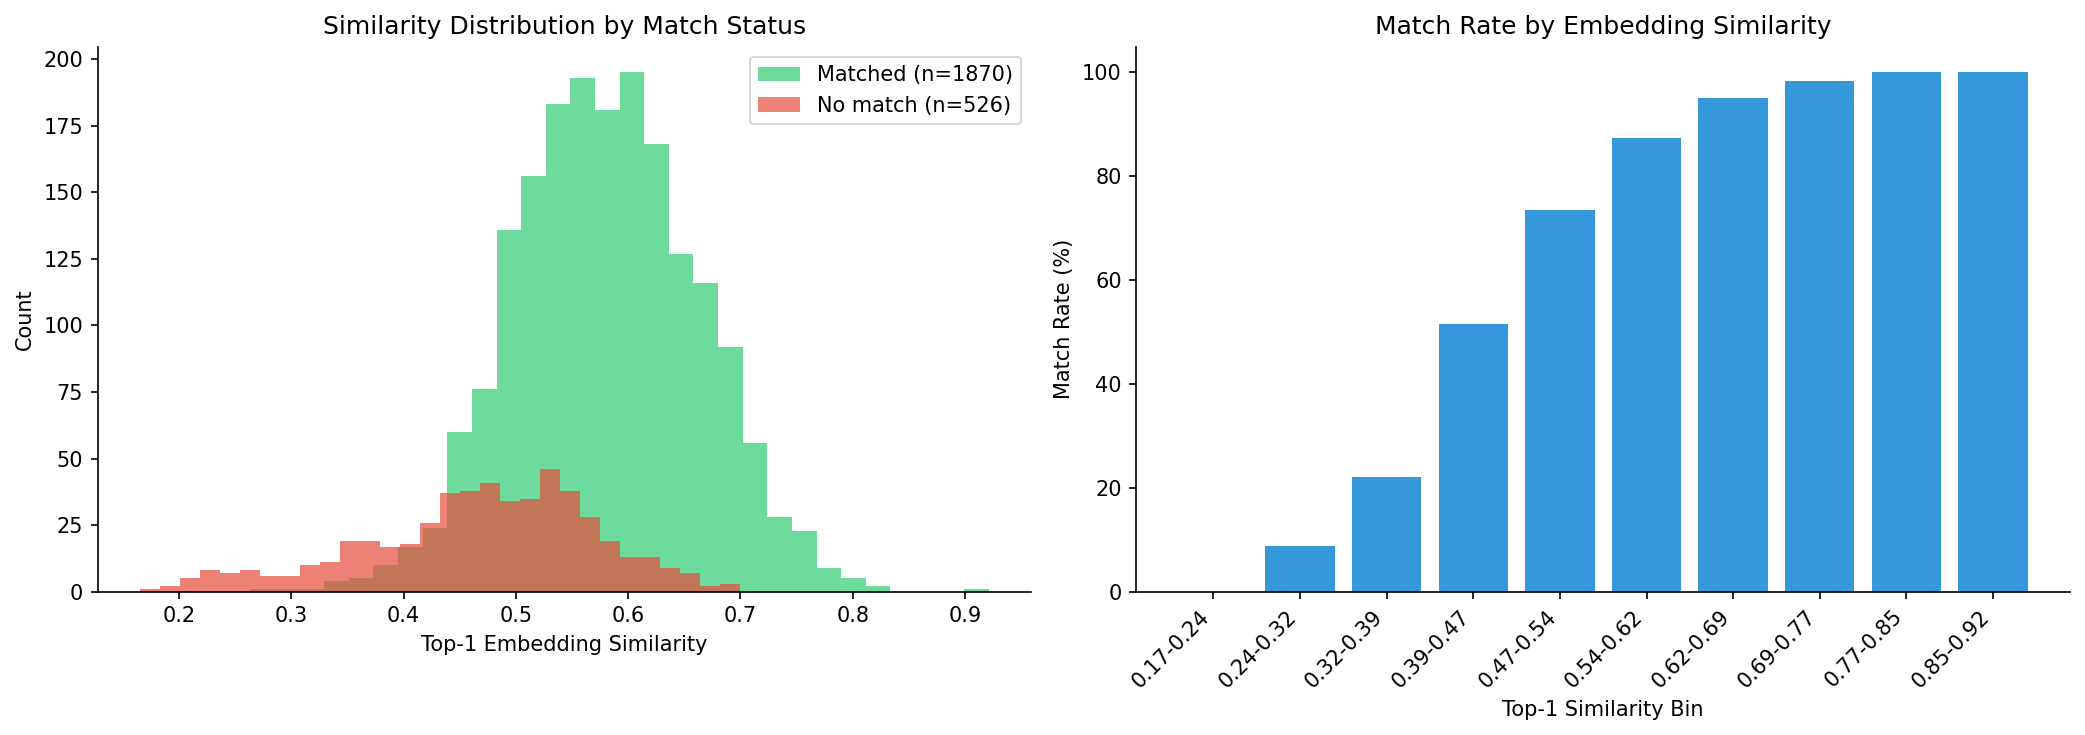

In [22]:
# =============================================================================
# G.1 COVERAGE AND MATCHABILITY ANALYSIS
# =============================================================================

if validated_unique is not None:
    # Unique-level stats
    n_unique = len(validated_unique)
    n_matched_unique = validated_unique['is_matched'].sum()
    match_rate_unique = n_matched_unique / n_unique * 100
    
    # Occurrence-weighted stats
    total_occurrences = validated_unique['occurrences'].sum()
    matched_occurrences = validated_unique[validated_unique['is_matched']]['occurrences'].sum()
    match_rate_weighted = matched_occurrences / total_occurrences * 100
    
    print("COVERAGE SUMMARY")
    print("=" * 60)
    print(f"Unique snippets: {n_unique}")
    print(f"  Matched: {n_matched_unique} ({match_rate_unique:.1f}%)")
    print(f"  Not matched: {n_unique - n_matched_unique} ({100 - match_rate_unique:.1f}%)")
    print(f"\nOccurrence-weighted:")
    print(f"  Total occurrences: {total_occurrences}")
    print(f"  Matched occurrences: {matched_occurrences} ({match_rate_weighted:.1f}%)")
    
    # Top-1 similarity distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram by match status
    ax = axes[0]
    matched_sims = validated_unique[validated_unique['is_matched']]['top1_similarity']
    unmatched_sims = validated_unique[~validated_unique['is_matched']]['top1_similarity']
    
    ax.hist(matched_sims, bins=30, alpha=0.7, label=f'Matched (n={len(matched_sims)})', color='#2ECC71')
    ax.hist(unmatched_sims, bins=30, alpha=0.7, label=f'No match (n={len(unmatched_sims)})', color='#E74C3C')
    ax.set_xlabel('Top-1 Embedding Similarity')
    ax.set_ylabel('Count')
    ax.set_title('Similarity Distribution by Match Status')
    ax.legend()
    
    # Match rate by similarity bin
    ax = axes[1]
    validated_unique['sim_bin'] = pd.cut(validated_unique['top1_similarity'], bins=10)
    match_by_bin = validated_unique.groupby('sim_bin')['is_matched'].mean() * 100
    
    x_labels = [f'{interval.left:.2f}-{interval.right:.2f}' for interval in match_by_bin.index]
    ax.bar(range(len(match_by_bin)), match_by_bin.values, color='#3498DB')
    ax.set_xticks(range(len(match_by_bin)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_xlabel('Top-1 Similarity Bin')
    ax.set_ylabel('Match Rate (%)')
    ax.set_title('Match Rate by Embedding Similarity')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig_match_quality.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("[PLACEHOLDER] Coverage analysis requires LLM decisions.")

In [23]:
# =============================================================================
# G.2 CONCORDANCE: TOP O*NET TASK STATEMENTS
# =============================================================================

if validated_unique is not None and validated_unique['is_matched'].sum() > 0:
    matched_df = validated_unique[validated_unique['is_matched']].copy()
    
    # Top 25 overall (occurrence-weighted)
    top_tasks = matched_df.groupby('selected_task_text')['occurrences'].sum().sort_values(ascending=False).head(25)
    
    print("TOP 25 MATCHED O*NET TASK STATEMENTS (by occurrences)")
    print("=" * 70)
    for i, (task, count) in enumerate(top_tasks.items(), 1):
        print(f"{i:2d}. ({count:3d}x) {task[:65]}...")
    
    # Save
    top_tasks_df = pd.DataFrame({
        'onet_task_text': top_tasks.index,
        'occurrences': top_tasks.values,
        'percent': (top_tasks.values / matched_df['occurrences'].sum() * 100).round(2)
    })
    top_tasks_df.to_csv(OUTPUT_DIR / "top_onet_tasks_overall.csv", index=False)
    print(f"\nSaved: {OUTPUT_DIR / 'top_onet_tasks_overall.csv'}")
else:
    print("[PLACEHOLDER] Concordance analysis requires matched snippets.")

TOP 25 MATCHED O*NET TASK STATEMENTS (by occurrences)
 1. ( 98x) ...
 2. ( 33x) Type, format, proofread, and edit correspondence and other docume...
 3. ( 28x) Prepare comprehensive written reports, presentations, maps, or ch...
 4. ( 27x) Write original content, such as headlines, cutlines, captions, an...
 5. ( 27x) Write reports....
 6. ( 26x) Create graphs, charts, or other visualizations to convey the resu...
 7. ( 21x) Compose explanatory summaries of contents of books and other refe...
 8. ( 20x) Manage schedules and set dates, times, and locations for meetings...
 9. ( 19x) Respond to user email inquiries, or set up automated systems to s...
10. ( 18x) Draft and type office memos....
11. ( 17x) Write text, such as stories, articles, editorials, or newsletters...
12. ( 17x) Design complex graphics and animation, using independent judgment...
13. ( 17x) Develop concepts or creative ideas for craft objects....
14. ( 16x) Develop or implement data analysis algorithms....
15. ( 16x)

In [24]:
# =============================================================================
# G.3 TAXONOMY GAPS (NO-MATCH SNIPPETS)
# =============================================================================

if validated_unique is not None:
    no_match_df = validated_unique[~validated_unique['is_matched']].copy()
    
    if len(no_match_df) > 0:
        # Top 50 no-match by occurrences
        top_gaps = no_match_df.nlargest(50, 'occurrences')[['task_key', 'example_snippet', 'occurrences', 'top1_similarity', 'sectors']]
        
        print("TOP 30 TAXONOMY GAPS (no-match snippets by occurrences)")
        print("=" * 70)
        for i, row in top_gaps.head(30).iterrows():
            print(f"({row['occurrences']:3d}x, sim={row['top1_similarity']:.2f}) {row['task_key'][:50]}...")
        
        # Save
        top_gaps.to_csv(OUTPUT_DIR / "taxonomy_gaps_top50.csv", index=False)
        print(f"\nSaved: {OUTPUT_DIR / 'taxonomy_gaps_top50.csv'}")
        
        # Gap analysis by sector
        print("\nNo-match rate by sector:")
        if validated_instances is not None:
            for sector in validated_instances['sector'].dropna().unique():
                sector_df = validated_instances[validated_instances['sector'] == sector]
                gap_rate = (~sector_df['is_matched']).mean() * 100
                print(f"  {sector}: {gap_rate:.1f}% not matched")
else:
    print("[PLACEHOLDER] Taxonomy gap analysis requires LLM decisions.")

TOP 30 TAXONOMY GAPS (no-match snippets by occurrences)
(  4x, sim=0.53) with ai tools...
(  3x, sim=0.38) which were not previously part of my role...
(  3x, sim=0.56) ai tools now allow me to handle tasks such as draf...
(  2x, sim=0.28) nothing at all all good...
(  2x, sim=0.49) making my work easier...
(  2x, sim=0.24) it s absolutely amazing...
(  2x, sim=0.46) with the help of ai...
(  2x, sim=0.22) i don t know...
(  2x, sim=0.22) i m not sure...
(  2x, sim=0.63) studying and reading...
(  2x, sim=0.42) which were not previously part of my job...
(  2x, sim=0.60) tasks i can now perform myself include writing and...
(  2x, sim=0.26) yes i know a lot...
(  2x, sim=0.67) tasks at work...
(  2x, sim=0.23) i can t remember...
(  2x, sim=0.24) they are that good...
(  1x, sim=0.45) like tasks that i usually give to there beneath me...
(  1x, sim=0.40) linking my work to other previous works...
(  1x, sim=0.45) just more fresh ideas...
(  1x, sim=0.26) just as previous...
(  1x, sim=

In [25]:
# =============================================================================
# G.4 QUALITY AUDIT PACK
# =============================================================================

if validated_unique is not None and len(validated_unique) > 0:
    np.random.seed(42)
    
    audit_pack = {}
    
    # 20 random matched examples
    matched_df = validated_unique[validated_unique['is_matched']]
    if len(matched_df) >= 20:
        audit_pack['matched_sample'] = matched_df.sample(20)[['task_key', 'example_snippet', 'selected_task_text', 'top1_similarity', 'rationale']]
    
    # 20 random no-match examples
    no_match_df = validated_unique[~validated_unique['is_matched']]
    if len(no_match_df) >= 20:
        audit_pack['no_match_sample'] = no_match_df.sample(20)[['task_key', 'example_snippet', 'top1_similarity', 'rationale']]
    
    # 20 "hard cases" - low similarity but matched
    hard_cases = matched_df[matched_df['top1_similarity'] < 0.4].nlargest(20, 'occurrences')
    if len(hard_cases) > 0:
        audit_pack['hard_cases'] = hard_cases[['task_key', 'example_snippet', 'selected_task_text', 'top1_similarity', 'rationale']]
    
    # Print and save
    for name, df in audit_pack.items():
        print(f"\n{name.upper()} ({len(df)} examples):")
        print("-" * 60)
        for i, row in df.head(5).iterrows():
            print(f"  Snippet: {row['example_snippet'][:50]}...")
            if 'selected_task_text' in row:
                print(f"  -> O*NET: {row['selected_task_text'][:50]}...")
            print(f"     (sim={row['top1_similarity']:.3f})")
        
        df.to_csv(OUTPUT_DIR / f"audit_{name}.csv", index=False)
    
    print(f"\nAudit files saved to {OUTPUT_DIR}")
else:
    print("[PLACEHOLDER] Quality audit requires LLM decisions.")


MATCHED_SAMPLE (20 examples):
------------------------------------------------------------
  Snippet: Creating data-driven insights, generating first dr...
  -> O*NET: Plan and develop pre-production ideas into outline...
     (sim=0.519)
  Snippet: I can now handle things like quick research...
  -> O*NET: Conduct own research in field of expertise....
     (sim=0.463)
  Snippet: Assisting the customers to check more information ...
  -> O*NET: Identify interested and qualified customers to pro...
     (sim=0.719)
  Snippet: I started arranging payroll...
  -> O*NET: Prepare and process payroll information....
     (sim=0.639)
  Snippet: In terms of researching...
  -> O*NET: Conduct research in a particular field of knowledg...
     (sim=0.590)

NO_MATCH_SAMPLE (20 examples):
------------------------------------------------------------
  Snippet: schemes and others...
     (sim=0.475)
  Snippet: It makes me go deeper into my line of job than I u...
     (sim=0.387)
  Snippet: IT HAS

## H. Downstream Validation: Agreement with Exposure Scores

This section checks whether the validated task mapping aligns with your exposure scoring framework.

In [26]:
# =============================================================================
# H.1 EXPOSURE SCORE AGREEMENT CHECK (PLACEHOLDER)
# =============================================================================

# This section requires your task-level or SOC-level exposure scores
# Uncomment and adapt once you have the scores available

'''
# Example: Load task-level exposure scores
# exposure_scores = pd.read_csv("path/to/task_exposure_scores.csv")

# Join to validated mapping
# validated_with_exposure = validated_instances.merge(
#     exposure_scores[['statement_id', 'exposure_score']],
#     left_on='selected_statement_id',
#     right_on='statement_id',
#     how='left'
# )

# Define "high exposure" threshold (e.g., top quartile)
# threshold = exposure_scores['exposure_score'].quantile(0.75)
# validated_with_exposure['high_exposure'] = validated_with_exposure['exposure_score'] >= threshold

# Compare delegated vs enabled
# delegated = validated_with_exposure[validated_with_exposure['source'] == 'Q13_delegated']
# enabled = validated_with_exposure[validated_with_exposure['source'] == 'Q14_enabled']

# print("Agreement check: High-exposure rate by source")
# print(f"  Delegated (Q13): {delegated['high_exposure'].mean()*100:.1f}%")
# print(f"  Enabled (Q14): {enabled['high_exposure'].mean()*100:.1f}%")
'''

print("Exposure agreement check placeholder.")
print("To implement: load your exposure scores and join to validated_instances.")
print("Then compare high-exposure rates between Q13 (delegated) and Q14 (enabled).")

Exposure agreement check placeholder.
To implement: load your exposure scores and join to validated_instances.
Then compare high-exposure rates between Q13 (delegated) and Q14 (enabled).


## I. Toplines and QC

In [27]:
# =============================================================================
# I.1 GENERATE TOPLINES.TXT
# =============================================================================

toplines = []
toplines.append("O*NET TASK MAPPING VALIDATION - TOPLINES")
toplines.append("=" * 60)
toplines.append(f"Generated: {datetime.now().isoformat()}")
toplines.append(f"Embedding model: {EMBEDDING_MODEL}")
toplines.append("")

# Extraction stats
toplines.append("EXTRACTION")
toplines.append(f"  Respondents with Q13: {q13_valid.sum()}")
toplines.append(f"  Respondents with Q14: {q14_valid.sum()}")
toplines.append(f"  Snippet instances: {len(snippets_dedup)}")
toplines.append(f"  Unique task_keys: {len(unique_snippets)}")
toplines.append("")

# Match stats (if available)
if validated_unique is not None:
    n_matched = validated_unique['is_matched'].sum()
    n_total = len(validated_unique)
    match_rate = n_matched / n_total * 100
    
    toplines.append("MATCH QUALITY")
    toplines.append(f"  Unique snippets matched: {n_matched}/{n_total} ({match_rate:.1f}%)")
    
    if validated_instances is not None:
        weighted_rate = validated_instances['is_matched'].mean() * 100
        toplines.append(f"  Instance-weighted match rate: {weighted_rate:.1f}%")
    
    toplines.append("")
    
    # Top 5 matched tasks
    if validated_unique['is_matched'].sum() > 0:
        matched_df = validated_unique[validated_unique['is_matched']]
        top5 = matched_df.groupby('selected_task_text')['occurrences'].sum().nlargest(5)
        toplines.append("TOP 5 MATCHED O*NET TASKS")
        for task, count in top5.items():
            toplines.append(f"  ({count}x) {task[:50]}...")
        toplines.append("")
    
    # Top 5 gaps
    no_match = validated_unique[~validated_unique['is_matched']].nlargest(5, 'occurrences')
    toplines.append("TOP 5 TAXONOMY GAPS")
    for _, row in no_match.iterrows():
        toplines.append(f"  ({row['occurrences']}x) {row['task_key'][:50]}...")
else:
    toplines.append("MATCH QUALITY")
    toplines.append("  [Pending LLM batch job completion]")

# Write
toplines_path = OUTPUT_DIR / "toplines.txt"
with open(toplines_path, 'w') as f:
    f.write('\n'.join(toplines))

print('\n'.join(toplines))
print(f"\nSaved: {toplines_path}")

O*NET TASK MAPPING VALIDATION - TOPLINES
Generated: 2026-02-02T14:38:25.828887
Embedding model: sentence-transformers/all-MiniLM-L6-v2

EXTRACTION
  Respondents with Q13: 1399
  Respondents with Q14: 1201
  Snippet instances: 2463
  Unique task_keys: 2396

MATCH QUALITY
  Unique snippets matched: 1870/2396 (78.0%)
  Instance-weighted match rate: 77.8%

TOP 5 MATCHED O*NET TASKS
  (98x) ...
  (33x) Type, format, proofread, and edit correspondence a...
  (28x) Prepare comprehensive written reports, presentatio...
  (27x) Write original content, such as headlines, cutline...
  (27x) Write reports....

TOP 5 TAXONOMY GAPS
  (4x) with ai tools...
  (3x) which were not previously part of my role...
  (3x) ai tools now allow me to handle tasks such as draf...
  (2x) nothing at all all good...
  (2x) making my work easier...

Saved: /Users/bhargav/adu_dev/aisi-economy-index/nbs/__scratch/exposure_score_pipeline/outputs/validation_llm/toplines.txt


In [28]:
# =============================================================================
# I.2 FINAL QC CHECK
# =============================================================================

print("=" * 70)
print("QC CHECK")
print("=" * 70)

# Counts
print(f"\n1. EXTRACTION COUNTS")
print(f"   Snippet instances: {len(snippets_dedup)}")
print(f"   Unique task_keys: {len(unique_snippets)}")
print(f"   O*NET statements: {len(onet_statements)}")

# Candidate generation
print(f"\n2. CANDIDATE GENERATION")
print(f"   Candidates generated: {len(all_candidates)}")
if all_candidates:
    top1_sims = [v['top1_similarity'] for v in all_candidates.values()]
    print(f"   Top-1 similarity (median): {np.median(top1_sims):.3f}")

# LLM decisions
print(f"\n3. LLM DECISIONS")
if llm_decisions is not None:
    print(f"   Decisions parsed: {len(llm_decisions)}")
    print(f"   Decision distribution:")
    for dec, count in llm_decisions['decision'].value_counts().items():
        print(f"     {dec}: {count}")
else:
    print("   [Pending batch job]")

# Output files
print(f"\n4. OUTPUT FILES")
expected_files = [
    'survey_snippets_instances.csv',
    'unique_snippets.csv',
    'onet_statements.csv',
    'onet_statement_to_soc.csv',
    'onet_candidates_top5.csv',
    'llm_batch_requests.jsonl',
    'toplines.txt',
]

# Add conditional files
if llm_decisions is not None:
    expected_files.extend([
        'llm_decisions.csv',
        'validated_mapping_unique.csv',
        'validated_mapping_instances.csv',
        'top_onet_tasks_overall.csv',
        'taxonomy_gaps_top50.csv',
    ])

for f in expected_files:
    path = OUTPUT_DIR / f
    status = "OK" if path.exists() else "MISSING"
    print(f"   [{status}] {f}")

print(f"\n{'=' * 70}")
print("QC COMPLETE")
print(f"{'=' * 70}")

QC CHECK

1. EXTRACTION COUNTS
   Snippet instances: 2463
   Unique task_keys: 2396
   O*NET statements: 17538

2. CANDIDATE GENERATION
   Candidates generated: 2396
   Top-1 similarity (median): 0.561

3. LLM DECISIONS
   Decisions parsed: 2396
   Decision distribution:
     match: 1870
     no_match: 526

4. OUTPUT FILES
   [OK] survey_snippets_instances.csv
   [OK] unique_snippets.csv
   [OK] onet_statements.csv
   [OK] onet_statement_to_soc.csv
   [OK] onet_candidates_top5.csv
   [OK] llm_batch_requests.jsonl
   [OK] toplines.txt
   [OK] llm_decisions.csv
   [OK] validated_mapping_unique.csv
   [OK] validated_mapping_instances.csv
   [OK] top_onet_tasks_overall.csv
   [OK] taxonomy_gaps_top50.csv

QC COMPLETE
